In [0]:
sales_data = [
    (1001, "Hyderabad", "Electronics", "Laptop", 2, 65000, "Completed"),
    (1002, "Bangalore", "Electronics", "Mobile", 3, 25000, "Completed"),
    (1003, "Mumbai", "Furniture", "Chair", 5, 3500, "Pending"),
    (1004, "Delhi", "Furniture", "Table", 2, 12000, "Completed"),
    (1005, "Chennai", "Fashion", "Shoes", 4, 2500, "Completed"),
    (1006, "Pune", "Fashion", "Watch", 1, 8000, "Cancelled"),
    (1007, "Hyderabad", "Electronics", "TV", 1, 45000, "Completed"),
    (1008, "Mumbai", "Electronics", "Laptop", 2, 65000, "Completed"),
    (1009, "Delhi", "Furniture", "Chair", 3, 3500, "Pending"),
    (1010, "Bangalore", "Fashion", "Shoes", 5, 2500, "Completed"),
    (1011, "Chennai", "Electronics", "Mobile", 4, 25000, "Completed"),
    (1012, "Hyderabad", "Fashion", "Watch", 2, 8000, "Completed")
]

columns = [
    "order_id",
    "city",
    "category",
    "product",
    "quantity",
    "price",
    "status"
]

df = spark.createDataFrame(sales_data, columns)

display(df)


display(df.select("category").distinct())

from pyspark.sql.functions import col

df = df.withColumn(
    "revenue",
    col("quantity") * col("price")
)

display(df)

order_id,city,category,product,quantity,price,status
1001,Hyderabad,Electronics,Laptop,2,65000,Completed
1002,Bangalore,Electronics,Mobile,3,25000,Completed
1003,Mumbai,Furniture,Chair,5,3500,Pending
1004,Delhi,Furniture,Table,2,12000,Completed
1005,Chennai,Fashion,Shoes,4,2500,Completed
1006,Pune,Fashion,Watch,1,8000,Cancelled
1007,Hyderabad,Electronics,TV,1,45000,Completed
1008,Mumbai,Electronics,Laptop,2,65000,Completed
1009,Delhi,Furniture,Chair,3,3500,Pending
1010,Bangalore,Fashion,Shoes,5,2500,Completed


category
Electronics
Furniture
Fashion


order_id,city,category,product,quantity,price,status,revenue
1001,Hyderabad,Electronics,Laptop,2,65000,Completed,130000
1002,Bangalore,Electronics,Mobile,3,25000,Completed,75000
1003,Mumbai,Furniture,Chair,5,3500,Pending,17500
1004,Delhi,Furniture,Table,2,12000,Completed,24000
1005,Chennai,Fashion,Shoes,4,2500,Completed,10000
1006,Pune,Fashion,Watch,1,8000,Cancelled,8000
1007,Hyderabad,Electronics,TV,1,45000,Completed,45000
1008,Mumbai,Electronics,Laptop,2,65000,Completed,130000
1009,Delhi,Furniture,Chair,3,3500,Pending,10500
1010,Bangalore,Fashion,Shoes,5,2500,Completed,12500


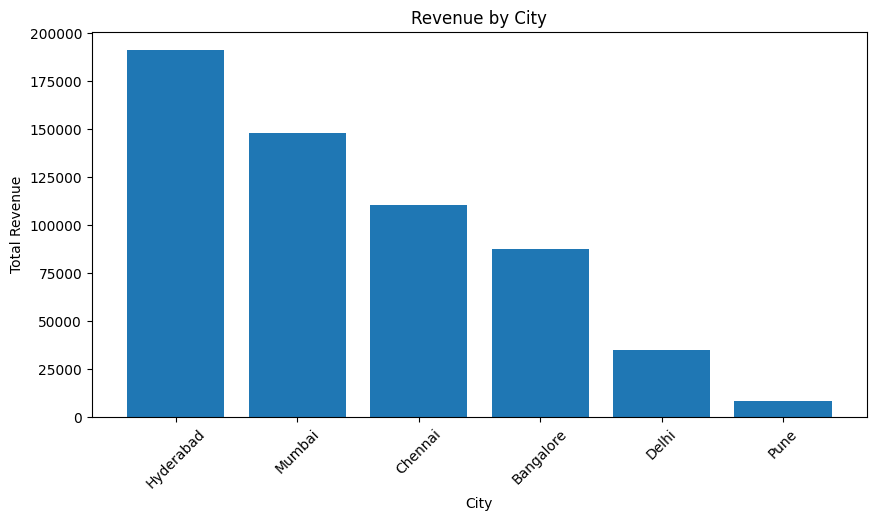

In [0]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import sum

city_revenue_df = df.groupBy("city").agg(
    sum("revenue").alias("total_revenue")
).orderBy(col("total_revenue").desc())

city_pd = city_revenue_df.toPandas()

plt.figure(figsize=(10, 5))
plt.bar(city_pd["city"], city_pd["total_revenue"])
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.title("Revenue by City")
plt.xticks(rotation=45)
plt.show()